#### Load the Covertype Data

In [74]:
from sklearn.datasets import fetch_covtype

# Load the Forest Cover Type dataset
covtype = fetch_covtype(as_frame=True)

# Examine the data head
covtype.data.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [75]:
print(covtype.data.columns)

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area_0',
       'Wilderness_Area_1', 'Wilderness_Area_2', 'Wilderness_Area_3',
       'Soil_Type_0', 'Soil_Type_1', 'Soil_Type_2', 'Soil_Type_3',
       'Soil_Type_4', 'Soil_Type_5', 'Soil_Type_6', 'Soil_Type_7',
       'Soil_Type_8', 'Soil_Type_9', 'Soil_Type_10', 'Soil_Type_11',
       'Soil_Type_12', 'Soil_Type_13', 'Soil_Type_14', 'Soil_Type_15',
       'Soil_Type_16', 'Soil_Type_17', 'Soil_Type_18', 'Soil_Type_19',
       'Soil_Type_20', 'Soil_Type_21', 'Soil_Type_22', 'Soil_Type_23',
       'Soil_Type_24', 'Soil_Type_25', 'Soil_Type_26', 'Soil_Type_27',
       'Soil_Type_28', 'Soil_Type_29', 'Soil_Type_30', 'Soil_Type_31',
       'Soil_Type_32', 'Soil_Type_33', 'Soil_Type_34', 'Soil_Type_35',
       'Soil_Type_36', 'S

#### Using Type 2 and 3 for Binary Classifier

In [76]:
# Going to use type 2 and 3
X = covtype.data
y = covtype.target

mask = y.isin([2,3])

# Filter
X = X[mask]
y = y[mask]

# Convert to Binary Classifier where type 3 is 1 and type 2 is 0 
y = y.map({
    2: 0,
3: 1
})

print(X.shape)
print(y.value_counts())

(319055, 54)
Cover_Type
0    283301
1     35754
Name: count, dtype: int64


#### Split the data and standardize the features

In [77]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Create training and test sets at the 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, train_size=0.8, random_state=45, stratify=y # stratify helps with same proportions of coverage for type 2 and type 3
)
# Standardize the features using standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Double check the shape to match the train/test % split
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (255244, 54)
Testing features shape: (63811, 54)


#### Perceptron Classifier

In [78]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize the classifier
perceptron_classifier = Perceptron(random_state=45)

# Fit the classifier on our training data
perceptron_classifier.fit(X_train_scaled, y_train)

# Make predictions on the standardized features 
y_pred_preceptron = perceptron_classifier.predict(X_test_scaled)

# accuracy
accuracy = accuracy_score(y_test, y_pred_preceptron)

# precision
precision = precision_score(y_test, y_pred_preceptron)

# recall
recall = recall_score(y_test, y_pred_preceptron)

# f1_score
f1 = f1_score(y_test, y_pred_preceptron)

print(f"Accuracy:  {accuracy}")
print(f"Precision: {precision}")
print(f"Recall:    {recall}")
print(f"F1-Score:  {f1}")

Accuracy:  0.9638463587782671
Precision: 0.8219888327572454
Recall:    0.8646343168787582
F1-Score:  0.842772439173993


#### Visualize the decision boundary using two selected features: Elevation and Aspect

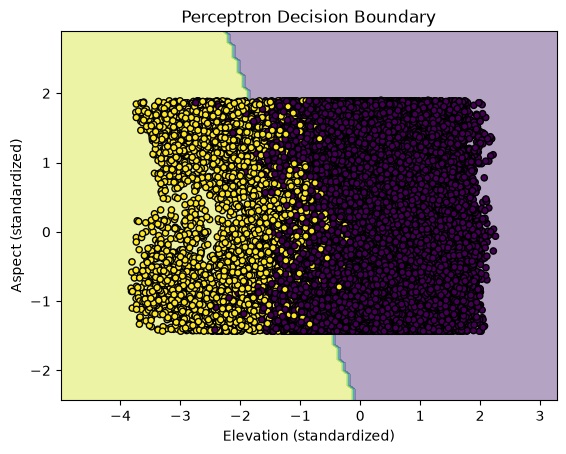

In [79]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import DecisionBoundaryDisplay

features = ["Elevation", "Aspect"]

# Step 1
X_train_2_features = X_train[features]
X_test_2_features = X_test[features]

# Step 2
scaler_features = StandardScaler()
X_train_2_features_scaled = scaler_features.fit_transform(X_train_2_features)
X_test_2_features_scaled= scaler_features.transform(X_test_2_features)

# Step 3 Train 2 feature Perceptron
perceptron_2d = Perceptron(random_state=45)
perceptron_2d.fit(X_train_2_features_scaled, y_train)

DecisionBoundaryDisplay.from_estimator(
    perceptron_2d,
    X_train_2_features_scaled,
    response_method="predict",
    alpha=0.4
)

plt.scatter(
    X_test_2_features_scaled[:, 0],
    X_test_2_features_scaled[:, 1],
    c=y_test,
    edgecolor="k",
    s=20
)

plt.xlabel("Elevation (standardized)")
plt.ylabel("Aspect (standardized)")
plt.title("Perceptron Decision Boundary")

plt.show()

#### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logitstic Regression classifier
LR_classifier = LogisticRegression(random_state=45)

# Fit the classifier on our training data
LR_classifier.fit(X_train_scaled, y_train)

# Make predictions on the standardized features 
y_pred_logist = LR_classifier.predict(X_test_scaled)

# accuracy
accuracy = accuracy_score(y_test, y_pred_logist)

# precision
precision = precision_score(y_test, y_pred_logist)

# recall
recall = recall_score(y_test, y_pred_logist)

# f1_score
f1 = f1_score(y_test, y_pred_logist)

print(f"Accuracy for Logistic Regression:  {accuracy}")
print(f"Precision for Logistic Regression: {precision}")
print(f"Recall for Logistic Regression:    {recall}")
print(f"F1-Score for Logistic Regression:  {f1}")

Accuracy for Logitstic Regression:  0.9753804203037094
Precision for Logitstic Regression: 0.888254940161425
Recall for Logitstic Regression:    0.8926024332261222
F1-Score for Logitstic Regression:  0.8904233800655647


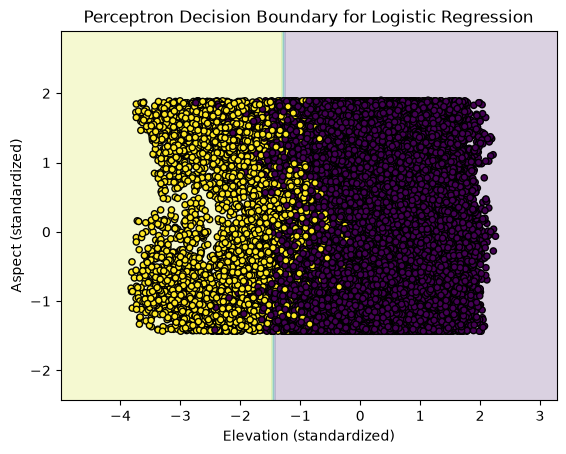

In [81]:
LR_classifier_2d = LogisticRegression(random_state=45)
LR_classifier_2d.fit(X_train_2_features_scaled, y_train)

DecisionBoundaryDisplay.from_estimator(
    LR_classifier_2d,
    X_train_2_features_scaled,
    response_method="predict",
    alpha=0.2
)

plt.scatter(
    X_test_2_features_scaled[:, 0],
    X_test_2_features_scaled[:, 1],
    c=y_test,
    edgecolor="k",
    s=20,
)

plt.xlabel("Elevation (standardized)")
plt.ylabel("Aspect (standardized)")
plt.title("Perceptron Decision Boundary for Logistic Regression")

plt.show()

#### Binary Cross Entropy for Logistic Regression

In [82]:
from sklearn.metrics import log_loss

# We need probability for BCE
y_prob = LR_classifier.predict_proba(X_test_scaled)

loss = log_loss(y_test, y_prob)
print(f"Binary Cross-Entropy Loss: {loss}")

Binary Cross-Entropy Loss: 0.06071754140077394


### Table of Results

| Model | Accuracy | Precision | Recall | F1-Score | BCE Loss |
|---|---:|---:|---:|---:|---:|
| Perceptron |0.9638463587782671|0.8219888327572454|0.8646343168787582|0.842772439173993| N/A |
| Logistic Regression |0.9753804203037094|0.888254940161425|0.8926024332261222|0.8904233800655647|0.06071754140077394|

